# Proyek Klasifikasi Gambar: Weather Image Dataset by Jehan Bhathena
- **Nama:** Muhammad Fathurahman
- **Email:** muhammad.220170212@mhs.unimal.ac.id
- **ID Dicoding:** arthurism

## Import Semua Packages/Library yang Digunakan

In [22]:
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten,
    Dense, Dropout, BatchNormalization, LeakyReLU
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split


## Data Preparation

### Data Loading

In [2]:
dataset_dir = 'dataset'

### Data Preprocessing

#### Split Dataset

In [3]:
train_dir = 'split_dataset/train'
test_dir = 'split_dataset/test'
val_dir = 'split_dataset/val'


for d in [train_dir, test_dir, val_dir]:
    if not os.path.exists(d):
        os.makedirs(d)


class_dirs = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]

for class_name in class_dirs:
    class_path = os.path.join(dataset_dir, class_name)
    image_files = [os.path.join(class_path, f) for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]


    train_files, test_files = train_test_split(image_files, test_size=0.3, random_state=42)
    test_files, val_files = train_test_split(test_files, test_size=0.6666666    , random_state=42)

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)


    for f in train_files:
        shutil.copy(f, os.path.join(train_dir, class_name, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(test_dir, class_name, os.path.basename(f)))
    for f in val_files:
        shutil.copy(f, os.path.join(val_dir, class_name, os.path.basename(f)))

print(f"Train data: {train_dir}")
print(f"Test data: {test_dir}")
print(f"Validation data: {val_dir}")

Train data: split_dataset/train
Test data: split_dataset/test
Validation data: split_dataset/val


### Check Datasets

In [4]:

def count_files_in_directory(directory):
  count = 0
  if os.path.exists(directory):
    for root, dirs, files in os.walk(directory):
      count += len(files)
  return count

print("\n--- Dataset Sizes ---")
print(f"Train dataset size: {count_files_in_directory(train_dir)} files")
print(f"Test dataset size: {count_files_in_directory(test_dir)} files")
print(f"Validation dataset size: {count_files_in_directory(val_dir)} files")

print("\n--- Class-wise Dataset Sizes ---")

for class_name in class_dirs:
    train_class_path = os.path.join(train_dir, class_name)
    test_class_path = os.path.join(test_dir, class_name)
    val_class_path = os.path.join(val_dir, class_name)

    print(f"Class '{class_name}':")
    print(f"  Train: {count_files_in_directory(train_class_path)} files")
    print(f"  Test: {count_files_in_directory(test_class_path)} files")
    print(f"  Validation: {count_files_in_directory(val_class_path)} files")



--- Dataset Sizes ---
Train dataset size: 4798 files
Test dataset size: 1372 files
Validation dataset size: 1378 files

--- Class-wise Dataset Sizes ---
Class 'dew':
  Train: 488 files
  Test: 140 files
  Validation: 140 files
Class 'fogsmog':
  Train: 595 files
  Test: 170 files
  Validation: 170 files
Class 'frost':
  Train: 332 files
  Test: 95 files
  Validation: 96 files
Class 'glaze':
  Train: 447 files
  Test: 128 files
  Validation: 128 files
Class 'hail':
  Train: 413 files
  Test: 118 files
  Validation: 119 files
Class 'lightning':
  Train: 263 files
  Test: 76 files
  Validation: 76 files
Class 'rain':
  Train: 368 files
  Test: 105 files
  Validation: 106 files
Class 'rainbow':
  Train: 162 files
  Test: 46 files
  Validation: 47 files
Class 'rime':
  Train: 812 files
  Test: 232 files
  Validation: 232 files
Class 'sandstorm':
  Train: 484 files
  Test: 138 files
  Validation: 139 files
Class 'snow':
  Train: 434 files
  Test: 124 files
  Validation: 125 files


In [5]:
def get_image_resolutions(directory):
  """
  Gets the resolution of all image files in a directory and its subdirectories.
  """
  resolutions = {}
  if os.path.exists(directory):
    for root, dirs, files in os.walk(directory):
      for file in files:
        filepath = os.path.join(root, file)
        try:
          with Image.open(filepath) as img:
            resolutions[filepath] = img.size
        except IOError:
          # Handle cases where the file is not an image or is corrupted
          pass
  return resolutions

# Get resolutions for all splits
print("\n--- Image Resolutions (Train) ---")
train_resolutions = get_image_resolutions(train_dir)
for img_path, resolution in train_resolutions.items():
  print(f"{img_path}: {resolution}")

print("\n--- Image Resolutions (Test) ---")
test_resolutions = get_image_resolutions(test_dir)
for img_path, resolution in test_resolutions.items():
  print(f"{img_path}: {resolution}")

print("\n--- Image Resolutions (Validation) ---")
val_resolutions = get_image_resolutions(val_dir)
for img_path, resolution in val_resolutions.items():
  print(f"{img_path}: {resolution}")


--- Image Resolutions (Train) ---
split_dataset/train\dew\2208.jpg: (950, 675)
split_dataset/train\dew\2209.jpg: (871, 578)
split_dataset/train\dew\2211.jpg: (1200, 797)
split_dataset/train\dew\2212.jpg: (947, 592)
split_dataset/train\dew\2213.jpg: (500, 411)
split_dataset/train\dew\2216.jpg: (500, 750)
split_dataset/train\dew\2217.jpg: (752, 500)
split_dataset/train\dew\2220.jpg: (720, 540)
split_dataset/train\dew\2221.jpg: (1000, 700)
split_dataset/train\dew\2222.jpg: (650, 398)
split_dataset/train\dew\2223.jpg: (400, 348)
split_dataset/train\dew\2224.jpg: (1024, 678)
split_dataset/train\dew\2225.jpg: (150, 94)
split_dataset/train\dew\2227.jpg: (400, 266)
split_dataset/train\dew\2228.jpg: (1024, 682)
split_dataset/train\dew\2229.jpg: (801, 534)
split_dataset/train\dew\2230.jpg: (800, 464)
split_dataset/train\dew\2231.jpg: (240, 160)
split_dataset/train\dew\2233.jpg: (1200, 1168)
split_dataset/train\dew\2234.jpg: (510, 304)
split_dataset/train\dew\2235.jpg: (266, 400)
split_dataset/t

### Cleaning Data 
Ada beberapa Data yang corrupt ketika di jalankan. Jadi saya melakukan pembersihan terhadap corrupt data

In [6]:
def find_and_remove_fully_corrupted_images(directory):
    corrupted = []
    total = 0
    if not os.path.exists(directory):
        print(f"Directory not found: {directory}")
        return []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                path = os.path.join(root, file)
                total += 1
                try:
                    with Image.open(path) as img:
                        # Check for empty images (0 dimension) and force load
                        if img.size[0] == 0 or img.size[1] == 0:
                             # Use PIL's check
                            img.verify() # Check file integrity without loading pixel data
                            raise ValueError("Empty or invalid image dimension")
                        img.load()  # Force load image data into memory

                except (UnidentifiedImageError, OSError, ValueError, Exception) as e:
                    print(f"❌ Corrupted: {path} ({type(e).__name__}: {e})")
                    corrupted.append(path)
                    try:
                        os.remove(path)
                        print(f"🧹 Removed: {path}")
                    except OSError as remove_error:
                        print(f"⚠️ Could not remove {path}: {remove_error}")

    print(f"\n🔍 Checked {total} files in {directory}.")
    print(f"🧹 Removed {len(corrupted)} corrupted images from {directory}.")
    return corrupted



### Resize and Augment data

In [7]:
# Defenisikan resolusi  data 
img_height = 128
img_width = 128


train_dir = 'split_dataset/train'
test_dir = 'split_dataset/test'
val_dir = 'split_dataset/val'



print("Cleaning train directory...")
find_and_remove_fully_corrupted_images(train_dir)
print("\nCleaning validation directory...")
find_and_remove_fully_corrupted_images(val_dir)
print("\nCleaning test directory...")
find_and_remove_fully_corrupted_images(test_dir)


# --- Augmentasi untuk training data ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

# --- Tidak ada augmentasi untuk validation/test ---
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)



Cleaning train directory...

🔍 Checked 4798 files in split_dataset/train.
🧹 Removed 0 corrupted images from split_dataset/train.

Cleaning validation directory...

🔍 Checked 1378 files in split_dataset/val.
🧹 Removed 0 corrupted images from split_dataset/val.

Cleaning test directory...

🔍 Checked 1372 files in split_dataset/test.
🧹 Removed 0 corrupted images from split_dataset/test.


### Memastikan Data tidak kosong

In [8]:
try:
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(img_height, img_width),
        batch_size=32,
        class_mode='categorical',
        shuffle=True  # penting untuk training
    )
except Exception as e:
    print(f"Error creating train_generator: {e}")
    print(f"Check if {train_dir} exists and contains subdirectories with images.")
    raise # Re-raise the exception to stop execution if generator creation failed


try:
    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(img_height, img_width),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )
except Exception as e:
    print(f"Error creating val_generator: {e}")
    print(f"Check if {val_dir} exists and contains subdirectories with images.")
    raise


try:
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(img_height, img_width),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )
except Exception as e:
     print(f"Error creating test_generator: {e}")
     print(f"Check if {test_dir} exists and contains subdirectories with images.")
     raise


print(f"\nImage data generators created with target size ({img_height}, {img_width}) and augmentations for training.")

Found 4798 images belonging to 11 classes.
Found 1378 images belonging to 11 classes.
Found 1372 images belonging to 11 classes.

Image data generators created with target size (128, 128) and augmentations for training.


## Modelling

In [9]:
# Menggunakan Transfer Learning
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = True  

# Bangun model Sequential
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),
    Dense(11, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

d:\AR2R\submissions\ar2rvenv\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,771 (10.00 MB)

 Trainable params: 2,586,891 (9.87 MB)

 Non-trainable params: 34,880 (136.25 KB)

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=1,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras', 
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1  
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-6
    )
]

epochs = 200
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks
)

d:\AR2R\submissions\ar2rvenv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.0947 - loss: 4.0279
Epoch 1: val_accuracy improved from -inf to 0.14659, saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 97s 568ms/step - accuracy: 0.0947 - loss: 4.0272 - val_accuracy: 0.1466 - val_loss: 3.0198 - learning_rate: 1.0000e-05
Epoch 2/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.1774 - loss: 3.4219
Epoch 2: val_accuracy improved from 0.14659 to 0.29245, saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 83s 555ms/step - accuracy: 0.1776 - loss: 3.4213 - val_accuracy: 0.2925 - val_loss: 2.7050 - learning_rate: 1.0000e-05
Epoch 3/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.2470 - loss: 3.0642
Epoch 3: val_accuracy improved from 0.29245 to 0.41147, saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 83s 553ms/step - accuracy: 0.2471 - loss: 3.0636 - val_accuracy: 0.4115 - val_loss: 2.4074 - learning_rate: 1.0000e-05
Epoch 4/200
150/150 ━━━━━

## Evaluasi dan Visualisasi

### Evaluasi

In [11]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8764 - loss: 0.9204
Test Loss: 1.0066142082214355
Test Accuracy: 0.851311981678009


### Visualisasi 

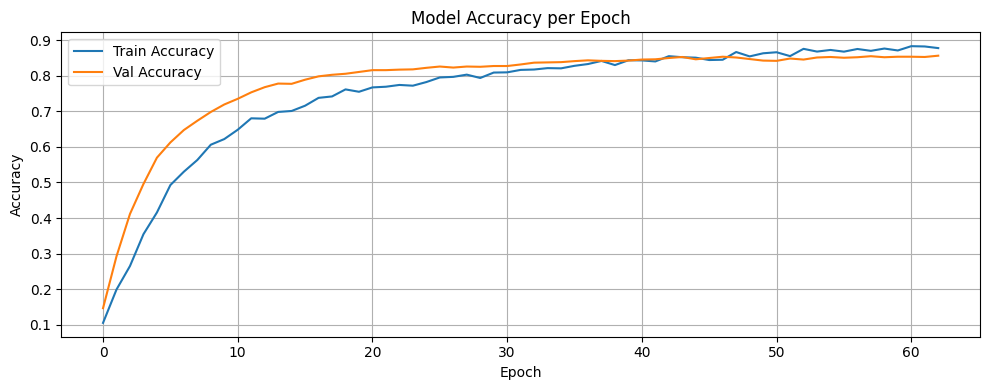

In [12]:

plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


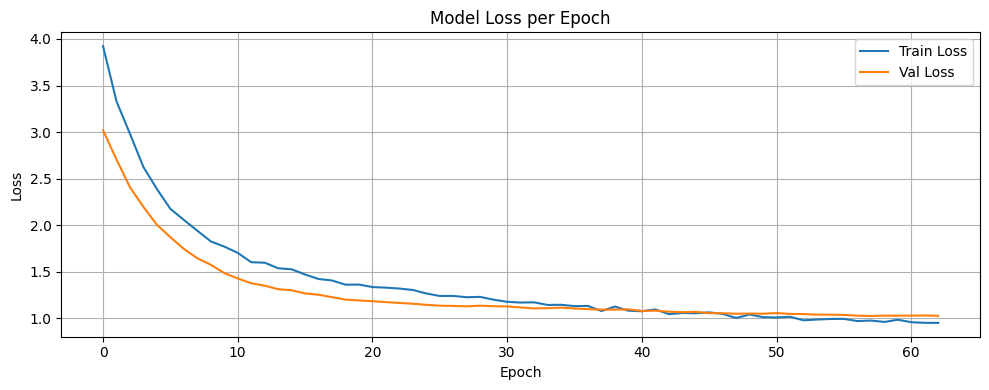

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Konversi Model

In [19]:

model.load_weights('best_model.keras')


saved_model_dir = 'model'
model.export(saved_model_dir)  

print(f"Model exported to {saved_model_dir} in SavedModel format")


converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()


tflite_path = 'tflite\model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved to {tflite_path}")

labels = list(train_generator.class_indices.keys())
labels_path = 'tflite\\labels.txt'

with open(labels_path, 'w') as f:
    for label in labels:
        f.write(label + '\n')

print(f"Label file saved to {labels_path}")


INFO:tensorflow:Assets written to: model\assets


INFO:tensorflow:Assets written to: model\assets


Saved artifact at 'model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  1837016712640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018296736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018296912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837016851200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837016853840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018300256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018337872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018338048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018323248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018324480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1837018341216: TensorSpec(shape=(), dtyp

## Inference (Optional)

### Load Model 

In [20]:

interpreter = tf.lite.Interpreter(model_path="tflite\\model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


d:\AR2R\submissions\ar2rvenv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Load Data dan Resize and use tflite model

In [23]:

folder_path = "sample_data" 
labels_path = "tflite\\labels.txt" 

with open(labels_path, 'r') as f:
    labels = f.read().splitlines()


for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(folder_path, filename)

        
        img = Image.open(img_path).resize((128, 128)).convert('RGB')
        img_array = np.array(img).astype(np.float32) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        
        interpreter.set_tensor(input_details[0]['index'], img_array)
        interpreter.invoke()

        
        output_data = interpreter.get_tensor(output_details[0]['index'])
        predicted_index = np.argmax(output_data)
        predicted_label = labels[predicted_index]

        print(f"{filename} ➜ {predicted_label} (confidence: {output_data[0][predicted_index]:.4f})")

glaze.jpg ➜ glaze (confidence: 0.6814)
lightning.jpg ➜ lightning (confidence: 0.9988)
rainbow.jpg ➜ rainbow (confidence: 1.0000)
